In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
with open('names.txt', 'r') as f:
    names = f.read().splitlines()
    chars = sorted(set((char for name in names for char in name)))

In [3]:
CHAR_SEP = '.'

In [4]:
SEQ_SIZE = 3
VOC_SIZE = 27
EMB_SIZE = 10
HID_SIZE = 200
BCH_SIZE = 128

In [5]:
i2c    = {i: c for i, c in enumerate(chars, 1)}
i2c[0] = CHAR_SEP
c2i    = {c: i for i, c in i2c.items()}

In [6]:
def get_dataset(sequence_size: int = 3, verbose=True):
    xs = []
    ys = []
    
    for i, name in enumerate(names):
        if verbose:
            print(f"name[{i}]: {name}")
        name += CHAR_SEP
        x = ''.join([CHAR_SEP] * SEQ_SIZE)
        for j in range(len(name)):
            y = name[j]
            xs.append([c2i[c] for c in x])
            ys.append(c2i[y])
            if verbose:
                print(f"{x} -> {y}")
            x = f"{x[1:]}{name[j]}"
    
    return torch.tensor(xs), torch.tensor(ys)

xs, ys = get_dataset(SEQ_SIZE, verbose=False)
xs.shape

torch.Size([228146, 3])

In [7]:
def split_dataset(xs, ys, tr=0.8, vl=0.1, ts=0.1):
    assert len(xs) == len(ys)
    assert abs(tr + vl + ts - 1.0) < 1e-6

    n = len(xs)

    n_tr = int(tr * n)
    n_vl = int(vl * n)

    xs_tr = xs[:n_tr]
    ys_tr = ys[:n_tr]

    xs_vl = xs[n_tr:n_tr + n_vl]
    ys_vl = ys[n_tr:n_tr + n_vl]

    xs_ts = xs[n_tr + n_vl:]
    ys_ts = ys[n_tr + n_vl:]

    return xs_tr, ys_tr, xs_vl, ys_vl, xs_ts, ys_ts

In [8]:
(
    xs_tr, ys_tr,
    xs_vl, ys_vl,
    xs_ts, ys_ts
) = split_dataset(xs, ys)

In [9]:
xs_tr.shape, xs_vl.shape, xs_ts.shape

(torch.Size([182516, 3]), torch.Size([22814, 3]), torch.Size([22816, 3]))

In [10]:
xs_tr.shape[0] + xs_vl.shape[0] + xs_ts.shape[0] == xs.shape[0]

True

#### Architecture

In [11]:
g = torch.Generator()
g.manual_seed(1777213731)

In [12]:
import functools
import operator

C = torch.randn((VOC_SIZE, EMB_SIZE), dtype=torch.float32, generator=g)
# C *= 0.01
C.requires_grad = True

W1 = torch.randn((SEQ_SIZE * EMB_SIZE, HID_SIZE), dtype=torch.float32, generator=g)
# W1 *= 0.01
W1.requires_grad = True
b1 = torch.zeros(HID_SIZE, dtype=torch.float32)
b1.requires_grad = True

W2 = torch.randn((HID_SIZE, VOC_SIZE), dtype=torch.float32, generator=g)
# W2 *= 0.01
W2.requires_grad = True
b2 = torch.zeros(VOC_SIZE, dtype=torch.float32)
b2.requires_grad = True

parameters = {
    'C': C,
    'W1': W1,
    'b1': b1,
    'W2': W2,
    'b2': b2,
}

total = sum((
    functools.reduce(operator.mul, p.shape)
    for p in parameters.values()
))
total

11897

In [13]:
def forward(xs):
    h_pre = C[xs].view(-1, SEQ_SIZE * EMB_SIZE) @ W1 + b1
    h_post = h_pre.tanh()
    logits = h_post.view(-1, HID_SIZE) @ W2 + b2
    return logits

#### Training

In [14]:
loss_tr = []
loss_vl = []

In [15]:
from collections import defaultdict

neuron_to_states = defaultdict(list)

for neuron, parameter in parameters.items():
    neuron_to_states[neuron].append((
        0,
        parameter.data.detach().cpu().flatten().tolist(),
        parameter.grad.detach().cpu().flatten().tolist() if parameter.grad else None
    ))
neuron_to_states['h_pre'].append((0, None, None))
neuron_to_states['h_post'].append((0, None, None))

In [16]:
epochs = 1000
log_every = 100

lrs = torch.linspace(1, 0, epochs)

for epoch in range(1, epochs + 1):
    # mini batch
    batch = torch.randint(0, xs_tr.shape[0], (BCH_SIZE,))
    
    # forward pass
    # logits = forward(xs_tr[batch])
    h_pre = C[xs_tr[batch]].view(-1, SEQ_SIZE * EMB_SIZE) @ W1 + b1
    h_post = h_pre.tanh()
    logits = h_post.view(-1, HID_SIZE) @ W2 + b2
    loss   = F.cross_entropy(logits, ys_tr[batch])
    
    # backward pass
    for parameter in parameters.values():
        parameter.grad = None
    loss.backward()
    loss_tr.append((epoch, loss.item()))

    # optimize
    lr = lrs[epoch - 1]
    for neuron, parameter in parameters.items():
        parameter.data += -lr * parameter.grad
        neuron_to_states[neuron].append((
            epoch, 
            parameter.data.detach().cpu().flatten().tolist(),
            parameter.grad.detach().cpu().flatten().tolist()
        ))
    neuron_to_states['h_pre'].append((
        epoch,
        h_pre.data.detach().cpu().flatten().tolist(),
        h_pre.grad.detach().cpu().flatten().tolist() if h_pre.grad else None
    ))
    neuron_to_states['h_post'].append((
        epoch,
        h_post.data.detach().cpu().flatten().tolist(),
        h_post.grad.detach().cpu().flatten().tolist() if h_post.grad else None
    ))
    
    # validate
    if epoch % log_every == 0:
        print(f"epoch[{epoch}] = {loss.item()}")

        with torch.no_grad():
            logits = forward(xs_vl)
            loss   = F.cross_entropy(logits, ys_vl)
            loss_vl.append((epoch, loss.item()))

logits = forward(xs_ts)
loss   = F.cross_entropy(logits, ys_ts)
loss

/var/folders/rp/5xgdthw53sn2b8gbxv7b0r240000gp/T/ipykernel_52447/1877460191.py:35: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  h_pre.grad.detach().cpu().flatten().tolist() if h_pre.grad else None
/var/folders/rp/5xgdthw53sn2b8gbxv7b0r240000gp/T/ipykernel_52447/1877460191.py:40: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-le

epoch[100] = 8.30479621887207
epoch[200] = 6.434542179107666
epoch[300] = 6.160867691040039
epoch[400] = 3.7318198680877686
epoch[500] = 3.4509148597717285
epoch[600] = 3.6984798908233643
epoch[700] = 2.678696632385254
epoch[800] = 2.474228858947754
epoch[900] = 2.4848947525024414
epoch[1000] = 2.3609206676483154


tensor(2.9417, grad_fn=<NllLossBackward0>)

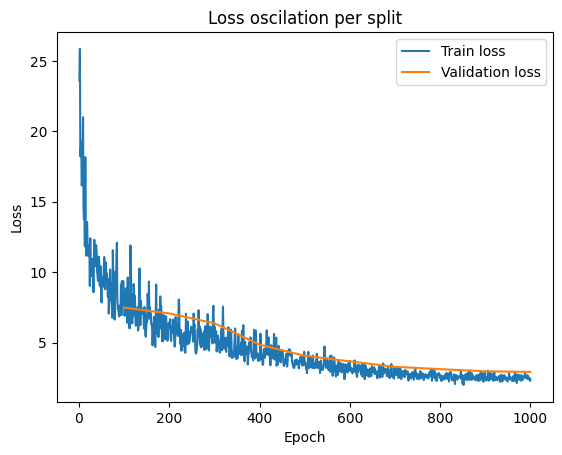

In [17]:
epochs_tr = [e for e, l in loss_tr]
losses_tr = [l for e, l in loss_tr]

epochs_vl = [e for e, l in loss_vl]
losses_vl = [l for e, l in loss_vl]
    
plt.title("Loss oscilation per split")
plt.plot(epochs_tr, losses_tr, label="Train loss")
plt.plot(epochs_vl, losses_vl, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##### Weights' gradients

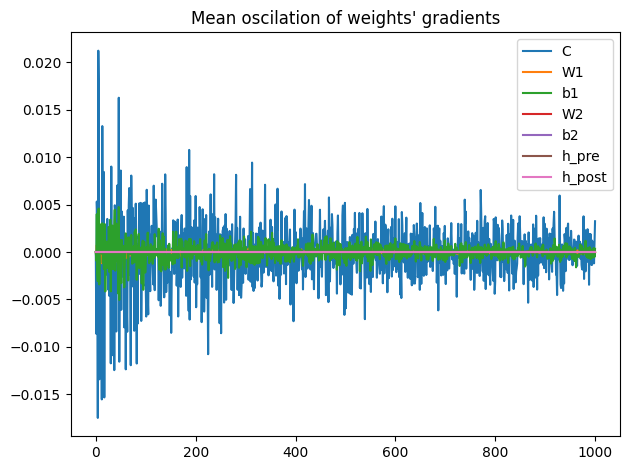

In [18]:
for neuron, parameters in neuron_to_states.items():
    epochs = [e for e, d, g in parameters]
    data = [np.mean(g) if g else 0.0 for e, d, g in parameters]
    plt.plot(epochs, data, label=neuron)
plt.title("Mean oscilation of weights' gradients")
plt.tight_layout()
plt.legend()
plt.show()

In [19]:
from ipywidgets import interact, IntSlider, Dropdown

def plot_grad_hist(epoch, neuron, bins):
    plt.figure(figsize=(6, 4))
    
    states = neuron_to_states.get(neuron, [])
    state = next((state for state in states if state[0] == epoch), None)
    
    if state is None:
        print("No data for this epoch/neuron")
        return
    
    data, grad = state[1], state[2]
    if grad is not None:
        plt.hist(grad, bins=bins, alpha=0.7)
    
    plt.title(f"Observing: neuron={neuron} | epoch={epoch}")
    plt.xlabel("Gradient")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

neurons = list(neuron_to_states.keys())
max_epoch = max(p[0] for pairs in neuron_to_states.values() for p in pairs)

interact(
    plot_grad_hist,
    epoch=IntSlider(min=0, max=max_epoch, step=1, value=0),
    neuron=Dropdown(options=neurons, value=neurons[0]),
    bins=IntSlider(min=5, max=100, step=5, value=25)
)

interactive(children=(IntSlider(value=0, description='epoch', max=1000), Dropdown(description='neuron', option…

<function __main__.plot_grad_hist(epoch, neuron, bins)>

##### Weights' data

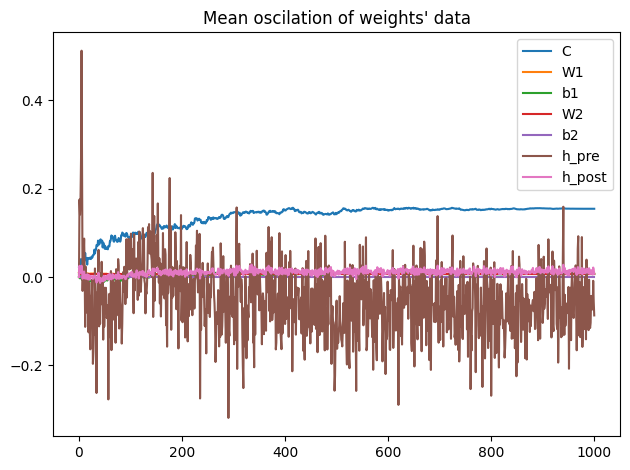

In [20]:
for neuron, parameters in neuron_to_states.items():
    epochs = [e for e, d, g in parameters]
    data = [np.mean(d) if d else 0.0 for e, d, g in parameters]
    plt.plot(epochs, data, label=neuron)
plt.title("Mean oscilation of weights' data")
plt.tight_layout()
plt.legend()
plt.show()

In [21]:
from ipywidgets import interact, IntSlider, Dropdown

def plot_data_hist(epoch, neuron, bins):
    plt.figure(figsize=(6, 4))
    
    states = neuron_to_states.get(neuron, [])
    state = next((state for state in states if state[0] == epoch), None)
    
    if state is None:
        print("No data for this epoch/neuron")
        return
    
    data, grad = state[1], state[2]
    if data is not None:
        plt.hist(data, bins=bins, alpha=0.7)
    
    plt.title(f"Observing: neuron={neuron} | epoch={epoch}")
    plt.xlabel("Data")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

neurons = list(neuron_to_states.keys())
max_epoch = max(p[0] for pairs in neuron_to_states.values() for p in pairs)

interact(
    plot_data_hist,
    epoch=IntSlider(min=0, max=max_epoch, step=1, value=0),
    neuron=Dropdown(options=neurons, value=neurons[0]),
    bins=IntSlider(min=5, max=100, step=5, value=25)
)

interactive(children=(IntSlider(value=0, description='epoch', max=1000), Dropdown(description='neuron', option…

<function __main__.plot_data_hist(epoch, neuron, bins)>

#### Inference

In [22]:
gen_names = []
for _ in range(10):
    gen_name = ''.join([CHAR_SEP] * SEQ_SIZE)
    while True:
        xs = torch.tensor([c2i[c] for c in gen_name[-SEQ_SIZE:]])
        logits = forward(xs)
        probs = torch.softmax(logits, dim=1)
        i = torch.multinomial(probs, 1,  replacement=True, generator=g).item()
        c = i2c[i]
        if c == CHAR_SEP:
            gen_names.append(gen_name[SEQ_SIZE:])
            break
        gen_name += c
gen_names

['kimbania',
 'monie',
 'javen',
 'railahay',
 'sasi',
 'laraxayse',
 'tamion',
 'bajrie',
 'moma',
 'koletteagonni']

#### Evaluation

In [23]:
nll = 0.0
count = 0
for name in names:
    xt = ''.join([CHAR_SEP] * SEQ_SIZE)
    for c in name:
        x = torch.tensor([c2i[c] for c in xt])
        y = torch.tensor([c2i[c]])
        logits = forward(x)
        nll += F.cross_entropy(logits, y)
        count += 1
        xt = f"{xt[1:]}{c}"
nll / count

tensor(2.7809, grad_fn=<DivBackward0>)